In [1]:
import sys
import os
os.chdir("/home/felixpersson/MasterThesisProject")
print(os.getcwd())

/home/felixpersson/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

import utils.sodium_properties as s_props
import data.dataclass as d_class

from models.heatpipe.heat_pipe_limitations_model import HeatPipeLimitations
from coupled.heatpipe import Heatpipe

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [3]:
import json
with open("./data/reactor_data.json", "r") as f:
    data_reactor = json.load(f)
    data = data_reactor["HeatPipe"]

Geometry warning: delta_wick changed from 0.00038933333333333344 to 0.0003650000000000003
Geometry warning: delta_gap changed from 0.0006813333333333335 to 0.0007300000000000006
Geometry warning: delta_wall changed from 0.00038933333333333344 to 0.0003650000000000003
Geometry warning: l_evap changed from 1.5 to 1.518
Geometry warning: l_adiabatic changed from 0.2 to 0.184
Geometry warning: l_cond changed from 0.6 to 0.598
[6.94830831e+06 6.78600835e+06 6.62795177e+06 6.47401650e+06
 6.32408424e+06 6.17804041e+06 6.03577400e+06 5.89717743e+06
 5.76214646e+06 5.63058007e+06 5.50238036e+06 5.37745243e+06
 5.25570428e+06 5.13704676e+06 5.02139340e+06 4.90866039e+06
 4.79876645e+06 4.69163277e+06 4.58718292e+06 4.48534278e+06
 4.38604044e+06 4.28920616e+06 4.19477229e+06 4.10267320e+06
 4.01284520e+06 3.92522652e+06 3.83975718e+06 3.75637900e+06
 3.67503553e+06 3.59567195e+06 3.51823506e+06 3.44267323e+06
 3.36893632e+06 3.29697565e+06 3.22674399e+06 3.15819544e+06
 3.09128543e+06 3.0259707

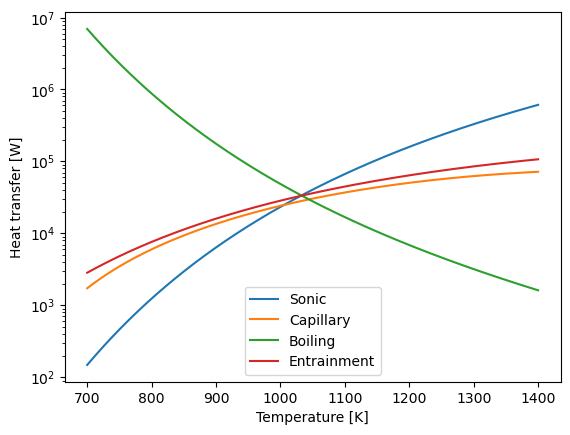

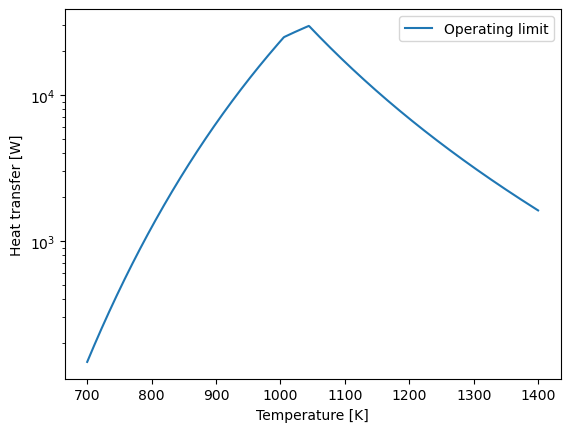

In [4]:
geom = d_class.HeatpipeGeometry(**data["geometry"])
mesh = d_class.HeatpipeMesh(N_R=20, N_Z=50)
mat = d_class.HeatpipeMaterial(**data["material"])
bc = d_class.HeatpipeBC(**data["bc"])
wick = d_class.HeatpipeWick(**data["wick"])
cfg = d_class.HeatpipeConfig(geom, mesh, mat, wick, bc)
cfg = cfg.resolve_geometry()

HP = Heatpipe(cfg)
HP_limits = HeatPipeLimitations(HP, cfg)

HP_limits.plot_analytical_limits(700, 1400)